# Importing pandas for data manipulation and analysis

In [2]:
import pandas as pd


# Importing NumPy for numerical computations

In [4]:
import numpy as np

# Loading the Titanic training and testing dataset 

In [6]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Displaingy the training dataset to inspect its structure.

In [8]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


i.e. We work on the training dataset because it contains both the input features and the target variable (Survived), allowing the model to learn patterns for making predictions.

# Generating summary statistics for the numerical columns in the training dataset.

In [11]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200




 train_df.describe() provides a statistical summary of the numerical features, including count, mean, standard deviation, minimum, maximum, and quartiles. It helps understand the data distribution, identify missing values, and detect potential outliers before building the machine learning model.


# Display the dataset structure, data types, and non-null values for each column.


In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB




`train_df.info()` shows that the Titanic dataset contains **891 rows and 12 columns** with a mix of **integer, float, and object (categorical/text)** data types. It also reveals missing values in the **Age (714 non-null), Cabin (204 non-null), and Embarked (889 non-null)** columns, indicating that these features require preprocessing before model training.


# <b> EDA(Exploratory Data Analysis) </b>

# Checking for duplicate rows in the dataset.


In [18]:
train_df.duplicated().sum()

0



This step checks for duplicate records in the dataset to ensure data quality before model training. The result is **0**, indicating that there are **no duplicate rows**, so no duplicate data needs to be removed.



# Checking missing values in each column


In [21]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64



This step identifies missing values in each column of the dataset. The results show that **Age** has **177** missing values, **Cabin** has **687**, and **Embarked** has **2**, while all other columns have no missing values. These missing values need to be handled during data preprocessing before training the machine learning model.


# Filling missing values in Age with the median

In [24]:

train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

The Age column contains **177** missing values. These are replaced with the **median age because the median is less affected by outliers than the mean**, making it a better choice for numerical data like age.

#  Fill missing values in Embarked with the mode


In [27]:
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

The Embarked column has only **2** missing values. These are replaced with the **mode (the most frequently occurring embarkation port)** since Embarked is a categorical variable.

# Droping the cabin column

In [30]:

train_df.drop('Cabin', axis=1, inplace=True)

The Cabin column has **687** missing values (over 77% of the data). Because such a large portion of the values is missing, the column provides limited information and is typically removed from the dataset.

# Verifying there is no missing values

In [33]:
train_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

The missing values were handled by filling the Age column with its median, filling the Embarked column with its mode, and dropping the Cabin column due to its high percentage of missing data. After these preprocessing steps, the dataset should no longer contain any missing values and will be ready for further exploratory data analysis and feature engineering.

# Checking for Outliers

Outliers are unusually high or low values that may affect the performance of a machine learning model. In the Titanic dataset, the numerical columns Age and Fare are commonly checked for outliers.

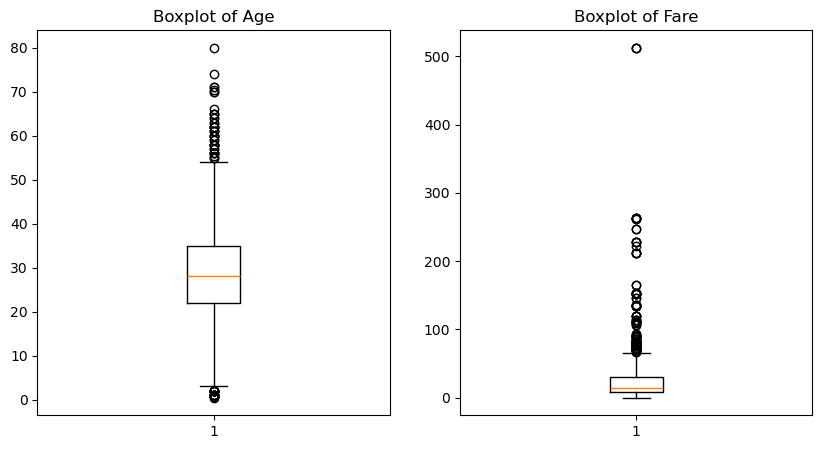

In [37]:
import matplotlib.pyplot as plt

# Create boxplots for Age and Fare
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot(train_df['Age'])
plt.title('Boxplot of Age')

plt.subplot(1, 2, 2)
plt.boxplot(train_df['Fare'])
plt.title('Boxplot of Fare')

plt.show()



Boxplots are used to visualize the distribution of the **Age** and **Fare** columns and identify potential outliers. Although both columns contain outliers, they represent genuine passenger information and are retained for model training.


# Check DataType

In [40]:
train_df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object



This step identifies the data type of each column, helping determine the appropriate preprocessing methods. The dataset contains both numerical and categorical features, so categorical columns must be encoded into numerical values before training the machine learning model.


# Statistical Summary

In [43]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



The `describe()` function provides statistical insights into numerical features, including their distribution and variation. The analysis shows different feature ranges, with passenger age averaging around 28 years and fare values showing significant variation due to high-value tickets.


# Analyzing Target Variables

The target variable tells us whether a passenger survived or not.

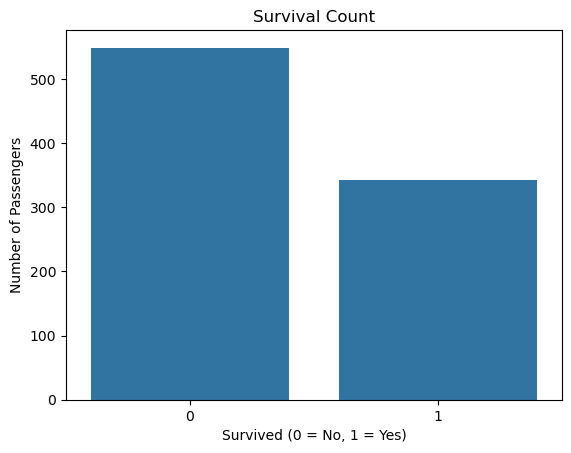

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot for survival
sns.countplot(x='Survived', data=train_df)

plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')

plt.show()

The count plot displays the number of passengers who **survived and did not survive**. The Survived column is the target variable that our machine learning model will predict.

# Analyze Gender Distribution

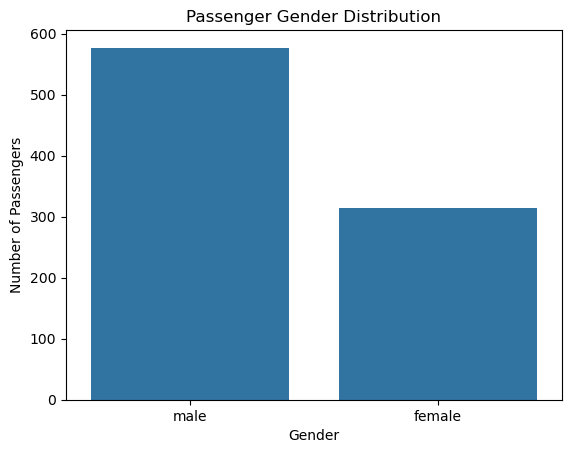

In [50]:
sns.countplot(x='Sex', data=train_df)

plt.title('Passenger Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.show()



The visualization shows the gender distribution of Titanic passengers, with a higher number of **male passengers than female passengers**. Gender is an important feature for prediction because it had a significant impact on passenger survival rates.


# Analyze Passenger Class (Pclass)


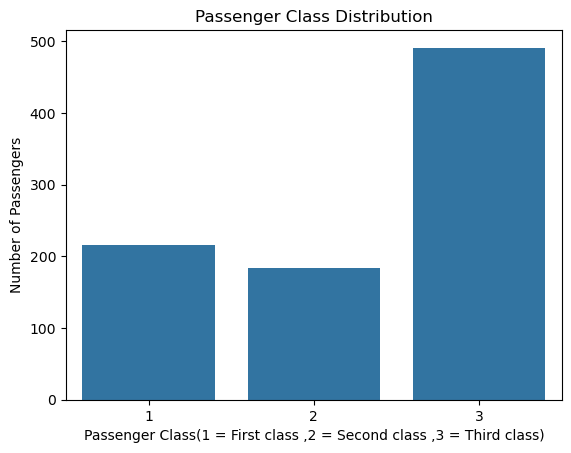

In [53]:
sns.countplot(x='Pclass', data=train_df)

plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class(1 = First class ,2 = Second class ,3 = Third class)')

plt.ylabel('Number of Passengers')

plt.show()



The visualization shows that most passengers belonged to **Third class**, while First-class passengers were fewer but had higher survival rates. `Pclass` represents passenger class (1 = First class, 2 = Second class, 3 = Third class) and is an important feature because social class influenced survival chances.


#  Analyzing Age Distribution

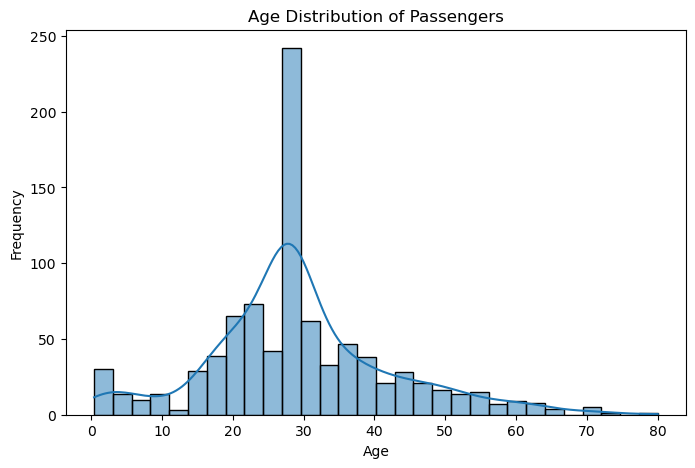

In [56]:
plt.figure(figsize=(8,5))

sns.histplot(train_df['Age'], bins=30, kde=True)

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()



The histogram with KDE curve shows the distribution of passenger ages in the Titanic dataset. Most passengers were between **20-40 years old**, with ages ranging from infants to elderly passengers, showing a slightly right-skewed distribution.



# Analyzing Fare Distribution

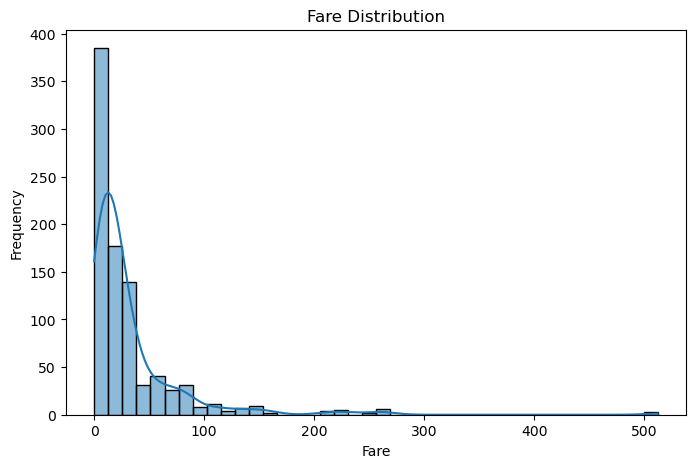

In [59]:
plt.figure(figsize=(8,5))

sns.histplot(train_df['Fare'], bins=40, kde=True)

plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.show()



The fare distribution shows that most passengers paid **lower ticket prices**, while a **few passengers paid significantly higher fares**. This right-skewed distribution reflects the higher ticket prices paid by passengers from higher classes.


# <b>Bivariate Analysis </b>

Bivariate analysis helps us understand the relationship between two variables. In the Titanic dataset, we mainly analyze how different features affected passenger survival.

# Survival Based on Gender (Sex)

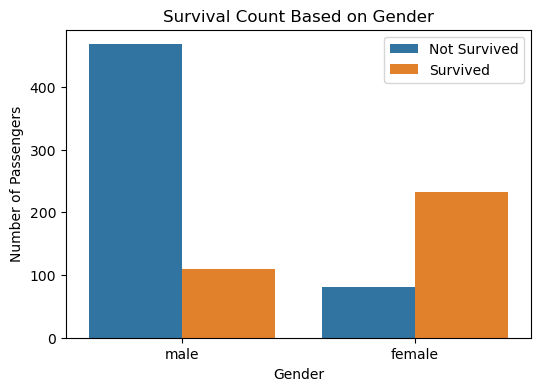

In [64]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sex', hue='Survived', data=train_df)

plt.title('Survival Count Based on Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(labels=['Not Survived', 'Survived'])

plt.show()



This plot shows the relationship between gender and survival. Female passengers had a much higher survival rate than male passengers, indicating that gender was an important factor in Titanic survival.

# Survival Based on Passenger Class

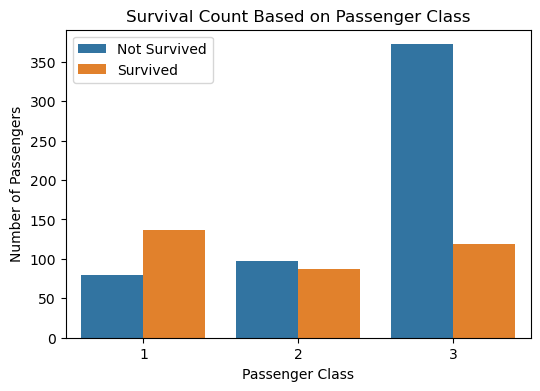

In [67]:
plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', hue='Survived', data=train_df)

plt.title('Survival Count Based on Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.legend(labels=['Not Survived', 'Survived'])

plt.show()

This plot shows how passenger class affected survival. First-class passengers had better survival chances, while third-class passengers had the highest number of deaths due to limited access to resources.

# Survival Rate Based on Gender and Class

<Figure size 800x500 with 0 Axes>

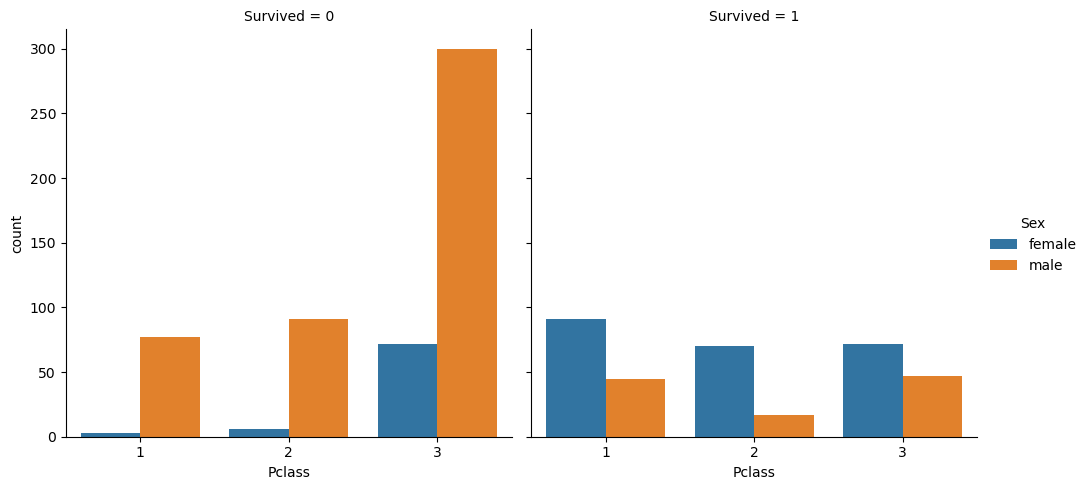

In [70]:
plt.figure(figsize=(8,5))

sns.catplot(
    x='Pclass',
    hue='Sex',
    col='Survived',
    data=train_df,
    kind='count'
)

plt.show()

This visualization compares survival across gender and passenger class. Female passengers, especially from first class, had the highest survival rate, while third-class males had the lowest survival chance.

# Survival Based on Age

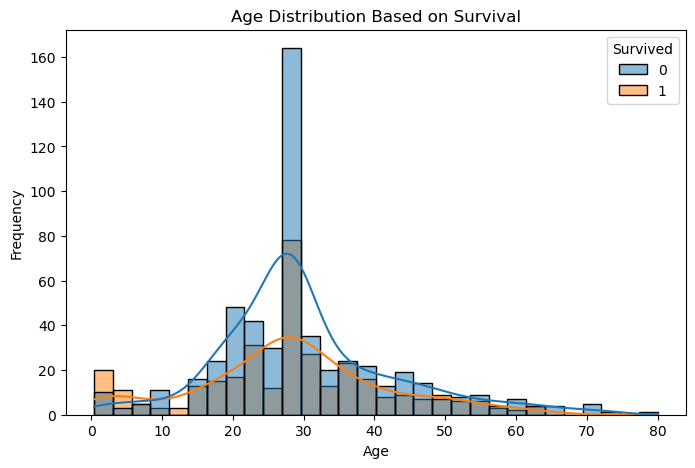

In [73]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=train_df,
    x='Age',
    hue='Survived',
    bins=30,
    kde=True
)

plt.title('Age Distribution Based on Survival')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

This plot shows the relationship between age and survival. Children had relatively higher survival chances, while most deaths occurred among adult passengers.

# Survival Based on Fare

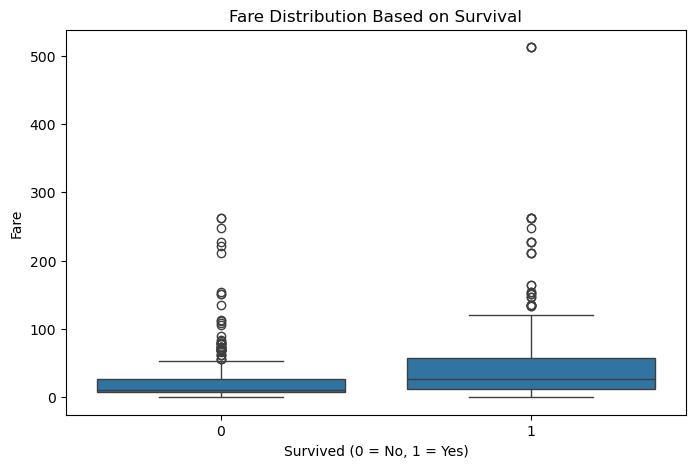

In [76]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Survived',
    y='Fare',
    data=train_df
)

plt.title('Fare Distribution Based on Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')

plt.show()

This plot shows the relationship between ticket fare and survival. Passengers who paid higher fares generally had better survival chances because they were mostly from higher passenger classes.

# Survival Based on Embarkation Port

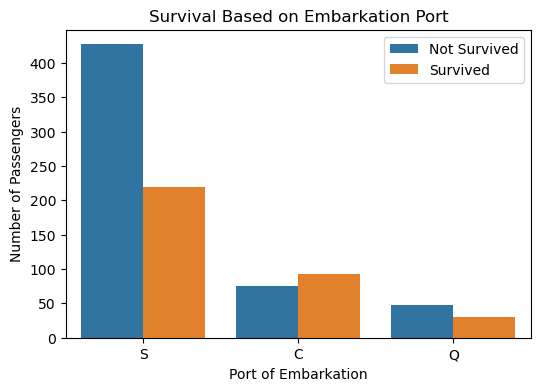

In [79]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Embarked',
    hue='Survived',
    data=train_df
)

plt.title('Survival Based on Embarkation Port')
plt.xlabel('Port of Embarkation')
plt.ylabel('Number of Passengers')

plt.legend(labels=['Not Survived', 'Survived'])

plt.show()

This plot shows survival differences based on the boarding location. Survival varied slightly among ports, mainly because passenger class distribution differed between embarkation points.

# Correlation Analysis between numerical features

Correlation shows how numerical features are related to each other.

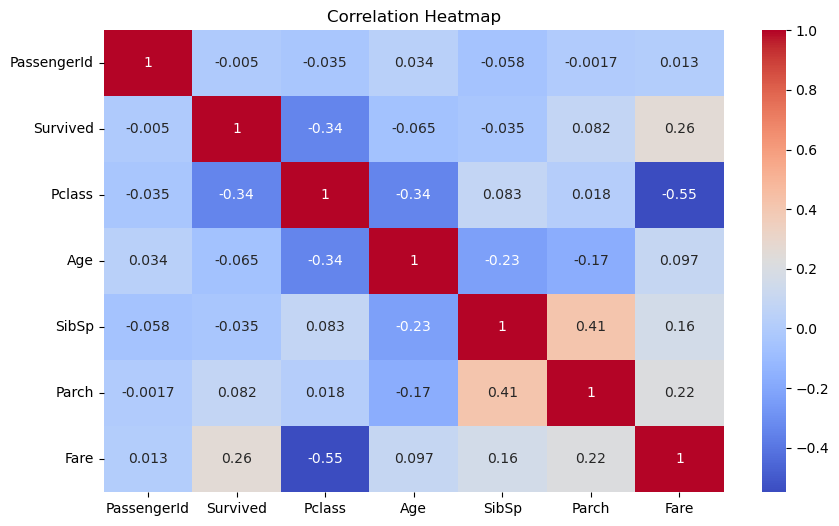

In [83]:
# Select numerical columns
numeric_data = train_df.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
correlation = numeric_data.corr()

# Visualize correlation
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows relationships between numerical variables. Features like **Pclass, Fare, Age, SibSp, and Parch** have different levels of influence on survival, helping us understand which features may be useful for machine learning.

# Survival Correlation with Numerical Features

In [86]:
# Correlation with target variable
correlation['Survived'].sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.064910
Pclass        -0.338481
Name: Survived, dtype: float64

This shows which numerical features have a stronger relationship with survival. **Positive values** indicate features that increase survival chances, while **negative values** indicate features associated with lower survival.

# Family Size Analysis

In [89]:
# Create FamilySize feature
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

train_df[['FamilySize', 'Survived']].head()

,FamilySize,Survived
0,2,0
1,2,1
2,1,1
3,2,1
4,1,0


The FamilySize feature represents the total number of family members traveling together. Family size can influence survival because passengers traveling alone or with very large families had different survival probabilities.

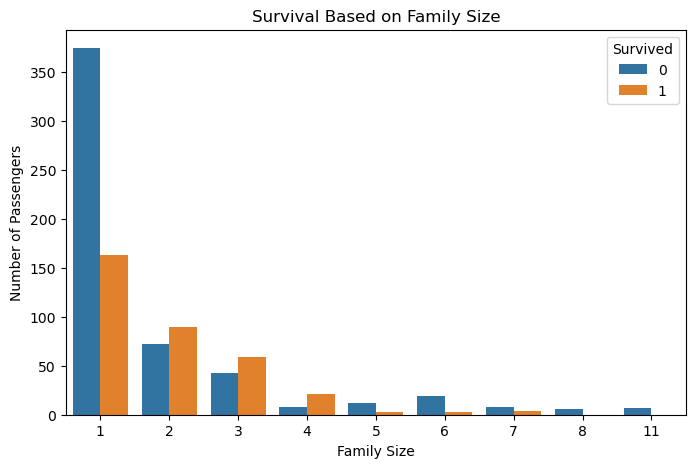

In [91]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='FamilySize',
    hue='Survived',
    data=train_df
)

plt.title('Survival Based on Family Size')
plt.xlabel('Family Size')
plt.ylabel('Number of Passengers')

plt.show()

This plot shows how family size affected survival. Passengers with small families had better survival chances, while passengers traveling alone or with very large families had lower survival rates.

# Create Title Feature from Name

In [94]:
# Extract titles from names
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

train_df['Title'].value_counts()

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/var/folders/hf/wwv96j7x4k72h7npdvq8xbx80000gn/T/ipykernel_5884/3483600264.py:2: SyntaxWarning: invalid escape sequence '\.'
  train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

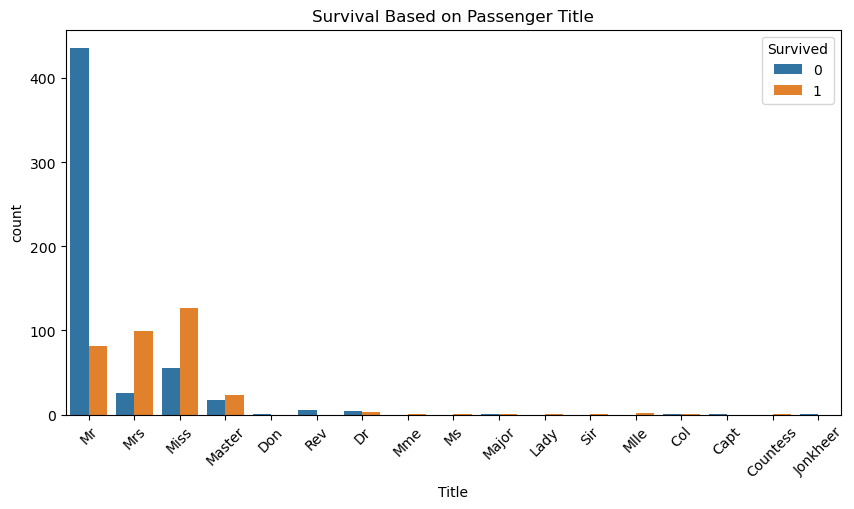

In [95]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Title',
    hue='Survived',
    data=train_df
)

plt.xticks(rotation=45)
plt.title('Survival Based on Passenger Title')

plt.show()

This analysis shows survival patterns based on passenger titles. Titles like Mrs and Miss had higher survival rates, while Mr had a higher number of deaths.

# <b> Feature Engineering & Data Preprocessing </b>

In [98]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize', 'Title'],
      dtype='object')

# Drop Unnecessary Columns

In [100]:
train_df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

These columns are removed because they contain unique values or text information that cannot directly be used by most machine learning algorithms. Removing irrelevant features helps reduce noise and improves model performance.

# Check Remaining Column

In [103]:
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Title
0,0,3,male,22.0,1,0,7.2500,S,2,Mr
1,1,1,female,38.0,1,0,71.2833,C,2,Mrs
2,1,3,female,26.0,0,0,7.9250,S,1,Miss
3,1,1,female,35.0,1,0,53.1000,S,2,Mrs
4,0,3,male,35.0,0,0,8.0500,S,1,Mr


# Convert Categorical Variables into Numerical Form

Machine learning algorithms work with numbers, so categorical features need encoding.

In [106]:
train_df.select_dtypes(include='object').columns

Index(['Sex', 'Embarked', 'Title'], dtype='object')

# Encode Gender (Sex)

In [108]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df['Sex'] = le.fit_transform(train_df['Sex'])

Label encoding converts categorical values into numerical values. Here, male and female are converted into numbers so that the machine learning model can process them.female → 0
male   → 1

# Encode Embarked and Title

In [111]:
train_df = pd.get_dummies(
    train_df,
    columns=['Embarked', 'Title'],
    drop_first=True
)

One-hot encoding converts categorical variables into separate binary columns. This allows the model to understand different categories without assuming any order between them.

# Final Dataset Check


In [114]:
train_df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S,...,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir
0,0,3,1,22.0,1,0,7.2500,2,False,True,...,False,False,False,False,False,True,False,False,False,False
1,1,1,0,38.0,1,0,71.2833,2,False,False,...,False,False,False,False,False,False,True,False,False,False
2,1,3,0,26.0,0,0,7.9250,1,False,True,...,False,False,True,False,False,False,False,False,False,False
3,1,1,0,35.0,1,0,53.1000,2,False,True,...,False,False,False,False,False,False,True,False,False,False
4,0,3,1,35.0,0,0,8.0500,1,False,True,...,False,False,False,False,False,True,False,False,False,False


In [115]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Survived        891 non-null    int64  
 1   Pclass          891 non-null    int64  
 2   Sex             891 non-null    int64  
 3   Age             891 non-null    float64
 4   SibSp           891 non-null    int64  
 5   Parch           891 non-null    int64  
 6   Fare            891 non-null    float64
 7   FamilySize      891 non-null    int64  
 8   Embarked_Q      891 non-null    bool   
 9   Embarked_S      891 non-null    bool   
 10  Title_Col       891 non-null    bool   
 11  Title_Countess  891 non-null    bool   
 12  Title_Don       891 non-null    bool   
 13  Title_Dr        891 non-null    bool   
 14  Title_Jonkheer  891 non-null    bool   
 15  Title_Lady      891 non-null    bool   
 16  Title_Major     891 non-null    bool   
 17  Title_Master    891 non-null    boo

# <b> Applying Machine Learning Models </b>

# Separate Features and Target Variable

In [118]:
# Features (independent variables)
X = train_df.drop('Survived', axis=1)

# Target variable (dependent variable)
y = train_df['Survived']

Here, we separate the dataset into features (X) and the target variable (y). The model will use the features to learn patterns and predict whether a passenger survived.

# Split Dataset into Training and Testing Data

In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

The dataset is divided into training and testing sets. **80%** of the data is used for training the model, while **20%** is used for evaluating model performance on unseen data.

# Check Dataset Shape

In [124]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Data: (712, 25)
Testing Data: (179, 25)
Training Target: (712,)
Testing Target: (179,)


The output confirms that the dataset has been successfully split. The training data will be used to build the model, while the testing data will measure how well the model performs.

# Feature Scaling

In [127]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Standard scaling transforms numerical features into a common range, improving model performance for algorithms sensitive to feature scales, such as Logistic Regression and Support Vector Machine.

# 1. Logistic Regression

In [130]:
from sklearn.linear_model import LogisticRegression
# Create model
logistic_model = LogisticRegression()

# Train model
logistic_model.fit(X_train, y_train)
# Predict on test data
y_pred = logistic_model.predict(X_test)

The trained model is used to predict survival outcomes for unseen test data. The predictions are compared with actual values to evaluate model performance.

In [132]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       105
           1       0.78      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



Accuracy measures the percentage of correct predictions made by the model. It shows how well Logistic Regression predicts passenger survival.**Also**The classification report provides detailed performance metrics such as precision, recall, and F1-score. These metrics help evaluate the model beyond simple accuracy.

# Confusion Matrix

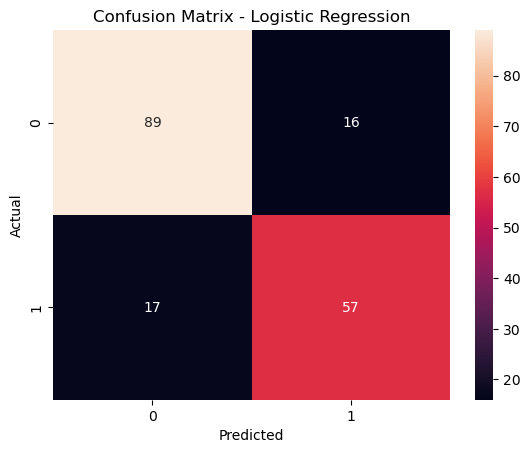

In [135]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

The confusion matrix evaluates the Logistic Regression model's prediction results. Out of 179 passengers, the model correctly classified 105 passengers (89 non-survivors and 16 survivors) and incorrectly classified 74 passengers (17 false survivors and 57 missed survivors).

# Applying Random Forest Model

In [138]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [139]:
# Create the model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8379888268156425

Confusion Matrix:
[[90 15]
 [14 60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       105
           1       0.80      0.81      0.81        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



Random Forest uses many decision trees and combines their predictions to improve accuracy and reduce overfitting.

# Applying Gradient Boosting

In [142]:
from sklearn.ensemble import GradientBoostingClassifier

In [143]:
# Create the model
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
gb_pred = gb_model.predict(X_test)

# Accuracy
gb_accuracy = accuracy_score(y_test, gb_pred)
print("Gradient Boosting Accuracy:", gb_accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 0.8100558659217877

Confusion Matrix:
[[91 14]
 [20 54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# Displaying all the acccuracy rate of 3 model

In [147]:
print(f"Logistic Regression Accuracy : {accuracy}")
print(f"Random Forest Accuracy       : {rf_accuracy}")
print(f"Gradient Boosting Accuracy   : {gb_accuracy}")

Logistic Regression Accuracy : 0.8156424581005587
Random Forest Accuracy       : 0.8379888268156425
Gradient Boosting Accuracy   : 0.8100558659217877


# Comparing all Models

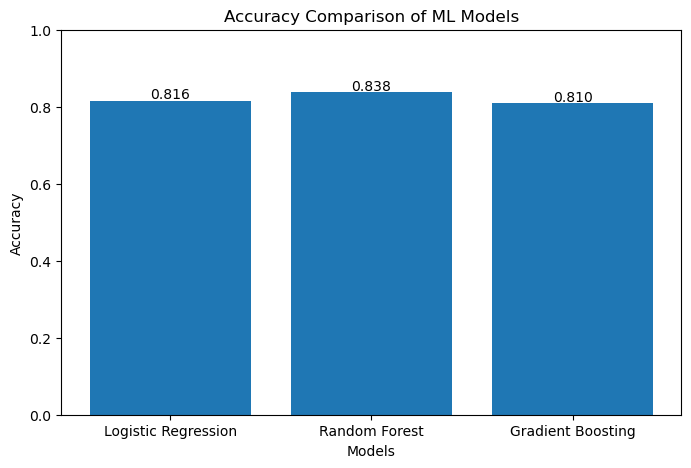

In [150]:
import matplotlib.pyplot as plt

# Model names
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']

# Accuracy values
accuracies = [accuracy, rf_accuracy, gb_accuracy]

# Plot bar chart
plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

# Title and labels
plt.title('Accuracy Comparison of ML Models')
plt.xlabel('Models')
plt.ylabel('Accuracy')

# Show accuracy values on top of each bar
for i, value in enumerate(accuracies):
    plt.text(i, value + 0.005, f'{value:.3f}', ha='center')

# Set y-axis limit
plt.ylim(0, 1)

plt.show()

The comparison of the three machine learning models shows that **Random Forest** achieved the highest accuracy among all the models tested on the Titanic dataset. This indicates that Random Forest was the most effective model for predicting passenger survival, as it captured the underlying patterns in the data better than Logistic Regression and Gradient Boosting.